In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("..")) 
from Datasets_n_simulator.simulator import simulate

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

In [29]:
infected_df = pd.read_csv("../Datasets_n_simulator/infected_timeseries.csv")
rewiring_df = pd.read_csv("../Datasets_n_simulator/rewiring_timeseries.csv")
degree_df = pd.read_csv("../Datasets_n_simulator/final_degree_histograms.csv")


In [30]:
infected_df = infected_df[infected_df["replicate_id"] == 0]
rewiring_df = rewiring_df[rewiring_df["replicate_id"] == 0]
degree_df = degree_df[degree_df["replicate_id"] == 0]
obs_infected = infected_df["infected_fraction"].values
obs_rewiring = rewiring_df["rewire_count"].values
obs_degree = degree_df["count"].values

In [31]:
def sample_prior(rng):
    beta = rng.uniform(0.05, 0.5)
    gamma = rng.uniform(0.02, 0.2)
    rho = rng.uniform(0.0, 0.8)
    return beta, gamma, rho

In [32]:
def compute_distances(summaries, s_obs):
    std = np.std(summaries, axis=0) + 1e-8
    dist = np.linalg.norm((summaries - s_obs) / std, axis=1)
    return dist

In [33]:
def rejection_abc_quantile(n_samples, s_obs, rng):
    thetas = []
    summaries = []

    for _ in range(n_samples):
        theta = sample_prior(rng)
        infected, rewiring, degree = simulate(*theta, rng=rng)

        s_sim = compute_summary(infected, rewiring, degree)

        thetas.append(theta)
        summaries.append(s_sim)

    thetas = np.array(thetas)           # shape (n, 3)
    summaries = np.array(summaries)     # shape (n, k)

    return thetas, summaries

In [34]:
def select_accepted(thetas, distances, quantile=0.05):
    epsilon = np.quantile(distances, quantile)

    indices = np.where(distances <= epsilon)[0]

    accepted_thetas = thetas[indices]

    return accepted_thetas, epsilon

In [35]:
rng = np.random.default_rng(42)
theta = sample_prior(rng)

In [36]:
def simulate_replicates(theta, R=40, rng=None):
    summaries = []
    for _ in range(R):
        infected, rewiring, degree = simulate(*theta, rng=rng)
        summaries.append(compute_summary(infected, rewiring, degree))
    return np.mean(summaries, axis=0)

In [37]:
# histogram plots of beta, rho, gamma
def plot_marginals(samples):
    beta = samples[:, 0]
    gamma = samples[:, 1]
    rho = samples[:, 2]

    # Means
    mean_beta = np.mean(beta)
    mean_gamma = np.mean(gamma)
    mean_rho = np.mean(rho)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot histograms and add mean lines
    axes[0].hist(beta, bins=30, color='skyblue', edgecolor='black')
    axes[0].axvline(mean_beta, color='red', linestyle='dashed', linewidth=2)
    axes[0].set_title(f"Posterior of β\nMean = {mean_beta:.2f}")

    axes[1].hist(gamma, bins=30, color='skyblue', edgecolor='black')
    axes[1].axvline(mean_gamma, color='red', linestyle='dashed', linewidth=2)
    axes[1].set_title(f"Posterior of γ\nMean = {mean_gamma:.2f}")

    axes[2].hist(rho, bins=30, color='skyblue', edgecolor='black')
    axes[2].axvline(mean_rho, color='red', linestyle='dashed', linewidth=2)
    axes[2].set_title(f"Posterior of ρ\nMean = {mean_rho:.2f}")

    plt.tight_layout()
    plt.show()

In [38]:
# pairwise scatter plot
def plot_pairwise(samples):
    beta = samples[:, 0]
    gamma = samples[:, 1]
    rho = samples[:, 2]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(beta, gamma, alpha=0.5)
    axes[0].set_xlabel("β")
    axes[0].set_ylabel("γ")
    axes[0].set_title("β vs γ")

    axes[1].scatter(beta, rho, alpha=0.5)
    axes[1].set_xlabel("β")
    axes[1].set_ylabel("ρ")
    axes[1].set_title("β vs ρ")

    axes[2].scatter(gamma, rho, alpha=0.5)
    axes[2].set_xlabel("γ")
    axes[2].set_ylabel("ρ")
    axes[2].set_title("γ vs ρ")

    plt.tight_layout()
    plt.show()

In [39]:
#acceptance rate
def plot_acceptance(epsilons, rates):
    plt.plot(epsilons, rates, marker='o')
    plt.xlabel("ε (tolerance)")
    plt.ylabel("Acceptance Rate")
    plt.title("Acceptance Rate vs Tolerance")
    plt.show()

In [40]:
#summary stats: 9
def compute_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring,
        peak_rewiring,
        mean_degree,
        var_degree,
        auc_to_peak_ratio
    ])

In [41]:
s_obs = compute_summary(obs_infected, obs_rewiring, obs_degree)
s_obs

array([5.40000000e-01, 9.00000000e+00, 0.00000000e+00, 9.90500000e+00,
       5.82000000e+02, 9.70000000e+01, 9.83000000e+00, 1.03411000e+01,
       1.83425926e+01])

In [42]:
s_sim = simulate_replicates(theta, R=40, rng=rng)

In [43]:
thetas, summaries = rejection_abc_quantile(
    n_samples=20000,
    s_obs=s_obs,
    rng=rng
)

In [44]:
dists = compute_distances(summaries, s_obs)
samples, epsilon = select_accepted(
    thetas,
    dists,
    quantile=0.05
)

print("Accepted samples:", samples.shape)
print("Epsilon used:", epsilon)

Accepted samples: (1000, 3)
Epsilon used: 1.4514657233441632


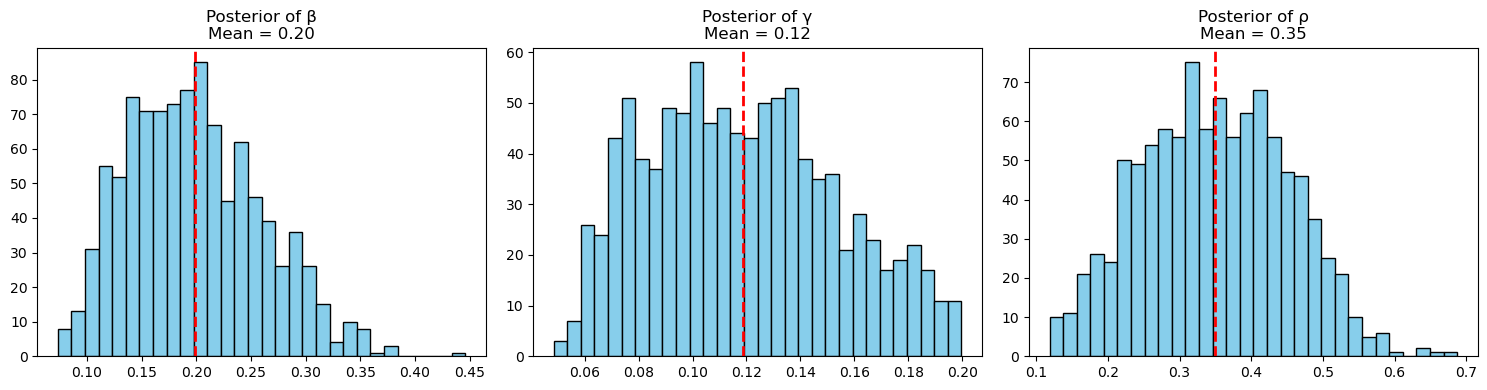

In [89]:
plot_marginals(samples)

In [46]:
# quantile-based epsilons
epsilons = np.quantile(dists, np.linspace(0.001, 0.1, 20))

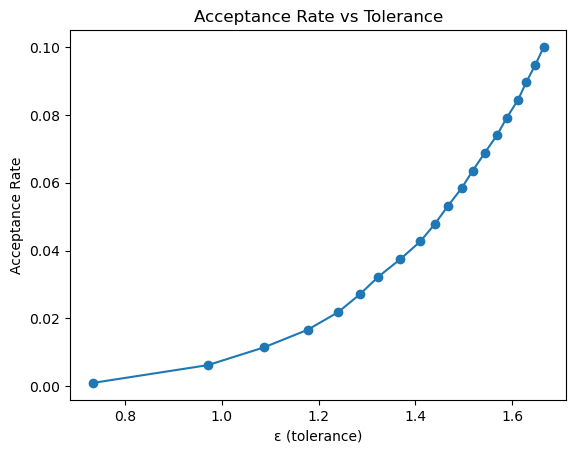

In [47]:
rates = []

for eps in epsilons:
    rate = np.mean(dists <= eps)
    rates.append(rate)

plot_acceptance(epsilons, rates)

In [48]:
#summary stats: 5
def compute_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring
    ])

In [49]:
s5_obs = compute_summary(obs_infected, obs_rewiring, obs_degree)
s5_obs

array([5.400e-01, 9.000e+00, 0.000e+00, 9.905e+00, 5.820e+02])

In [50]:
thetas5, summaries5 = rejection_abc_quantile(
    n_samples=20000,
    s_obs=s5_obs,
    rng=rng
)

In [51]:
dists5 = compute_distances(summaries5, s5_obs)
samples5, epsilon5 = select_accepted(
    thetas5,
    dists5,
    quantile=0.05
)

print("Accepted samples:", samples5.shape)
print("Epsilon used:", epsilon5)

Accepted samples: (1000, 3)
Epsilon used: 0.8062607141004964


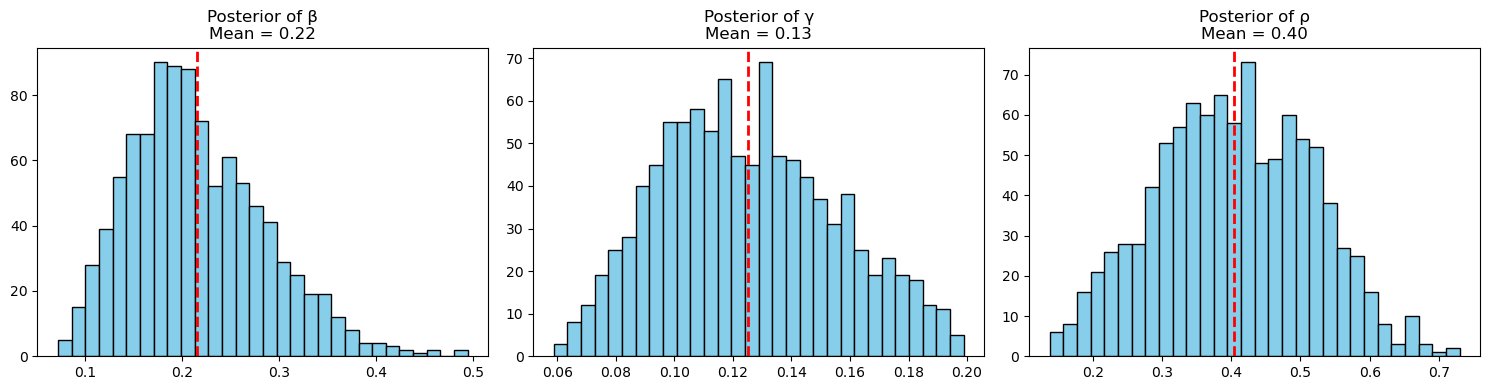

In [86]:
plot_marginals(samples5)

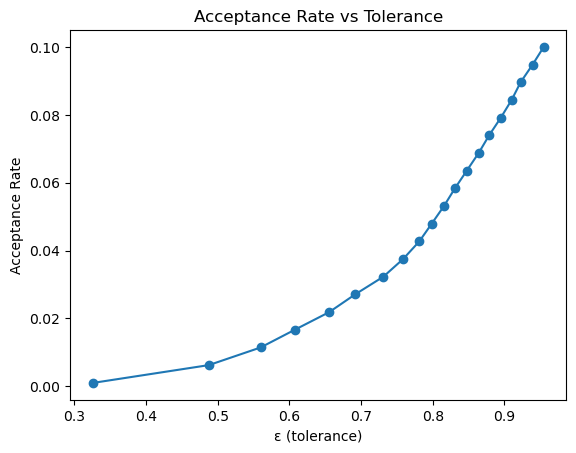

In [53]:
epsilons = np.quantile(dists5, np.linspace(0.001, 0.1, 20))
rates = []

for eps in epsilons:
    rate = np.mean(dists5 <= eps)
    rates.append(rate)

plot_acceptance(epsilons, rates)

In [54]:
#summary stats: 6
def compute_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)
    rewiring_timing = np.argmax(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring,
        rewiring_timing
    ])

In [55]:
s6_obs = compute_summary(obs_infected, obs_rewiring, obs_degree)
s6_obs

array([5.400e-01, 9.000e+00, 0.000e+00, 9.905e+00, 5.820e+02, 7.000e+00])

In [56]:
thetas6, summaries6 = rejection_abc_quantile(
    n_samples=20000,
    s_obs=s6_obs,
    rng=rng
)

In [57]:
dists6 = compute_distances(summaries6, s6_obs)
samples6, epsilon6 = select_accepted(
    thetas6,
    dists6,
    quantile=0.05
)

print("Accepted samples:", samples6.shape)
print("Epsilon used:", epsilon6)

Accepted samples: (1000, 3)
Epsilon used: 1.0203204609756622


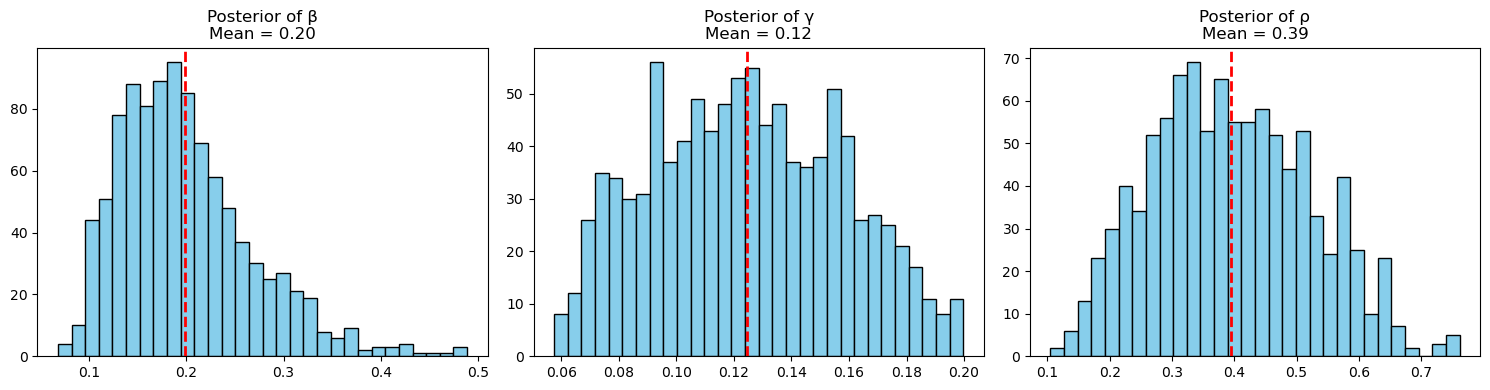

In [85]:
plot_marginals(samples6)

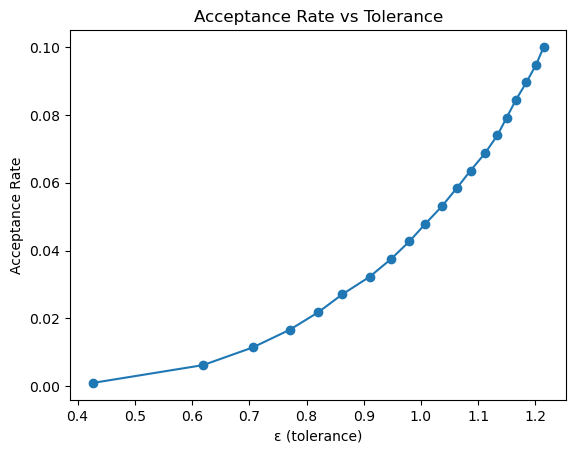

In [59]:
epsilons = np.quantile(dists6, np.linspace(0.001, 0.1, 20))
rates = []

for eps in epsilons:
    rate = np.mean(dists6 <= eps)
    rates.append(rate)

plot_acceptance(epsilons, rates)

In [60]:
#summary stats: 8
def compute_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring,
        peak_rewiring,
        mean_degree,
        var_degree
        #auc_to_peak_ratio,
    ])

In [61]:
s8_obs = compute_summary(obs_infected, obs_rewiring, obs_degree)
s8_obs

array([5.40000e-01, 9.00000e+00, 0.00000e+00, 9.90500e+00, 5.82000e+02,
       9.70000e+01, 9.83000e+00, 1.03411e+01])

In [62]:
thetas8, summaries8 = rejection_abc_quantile(
    n_samples=20000,
    s_obs=s8_obs,
    rng=rng
)

In [63]:
dists8 = compute_distances(summaries8, s8_obs)
samples8, epsilon8 = select_accepted(
    thetas8,
    dists8,
    quantile=0.05
)

print("Accepted samples:", samples8.shape)
print("Epsilon used:", epsilon)

Accepted samples: (1000, 3)
Epsilon used: 1.4514657233441632


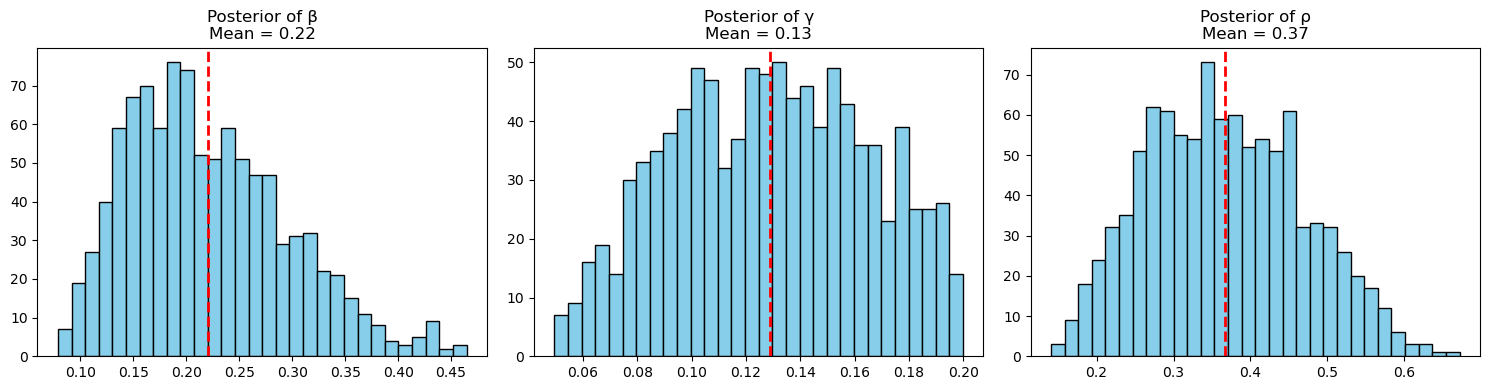

In [87]:
plot_marginals(samples8)

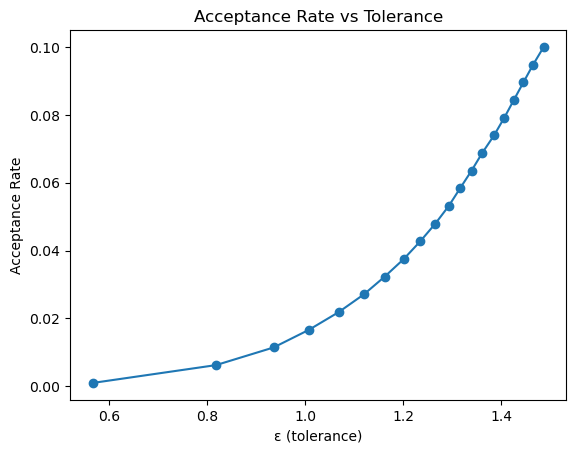

In [65]:
epsilons = np.quantile(dists8, np.linspace(0.001, 0.1, 20))
rates = []

for eps in epsilons:
    rate = np.mean(dists8 <= eps)
    rates.append(rate)

plot_acceptance(epsilons, rates)

In [66]:
#summary stats: w/o auc_to_peak_ratio
def compute_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)
    rewiring_timing = np.argmax(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring,
        peak_rewiring,
        mean_degree,
        var_degree,
        rewiring_timing
        #auc_to_peak_ratio,
    ])

In [67]:
sl_obs = compute_summary(obs_infected, obs_rewiring, obs_degree)
sl_obs

array([5.40000e-01, 9.00000e+00, 0.00000e+00, 9.90500e+00, 5.82000e+02,
       9.70000e+01, 9.83000e+00, 1.03411e+01, 7.00000e+00])

In [68]:
thetasl, summariesl = rejection_abc_quantile(
    n_samples=20000,
    s_obs=sl_obs,
    rng=rng
)

In [69]:
distsl = compute_distances(summariesl, sl_obs)
samplesl, epsilonl = select_accepted(
    thetasl,
    distsl,
    quantile=0.05
)

print("Accepted samples:", samplesl.shape)
print("Epsilon used:", epsilonl)

Accepted samples: (1000, 3)
Epsilon used: 1.4639070931568015


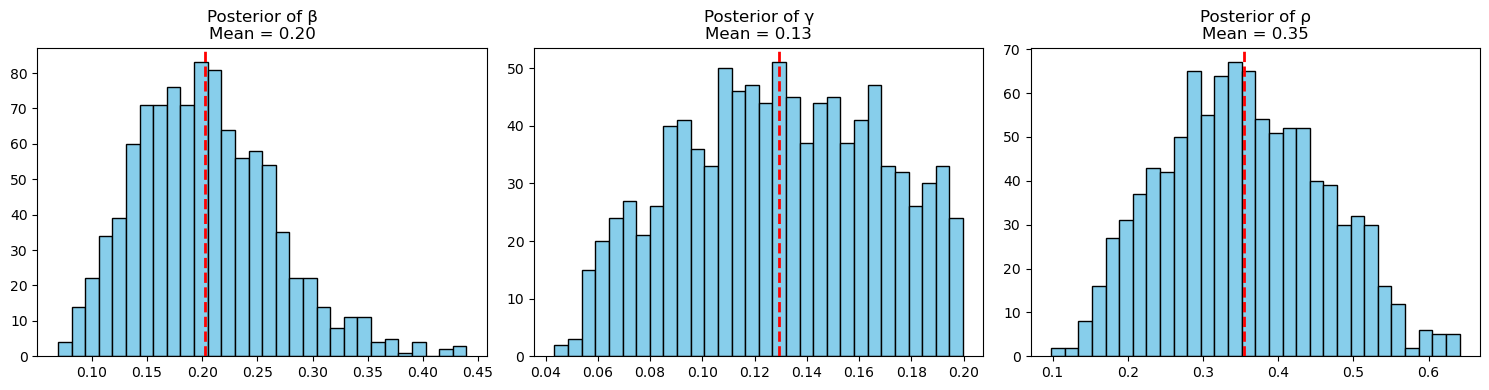

In [88]:
plot_marginals(samplesl)

In [71]:
epsilons = np.quantile(distsl, np.linspace(0.001, 0.1, 20))
rates = []

for eps in epsilons:
    rate = np.mean(distsl <= eps)
    rates.append(rate)

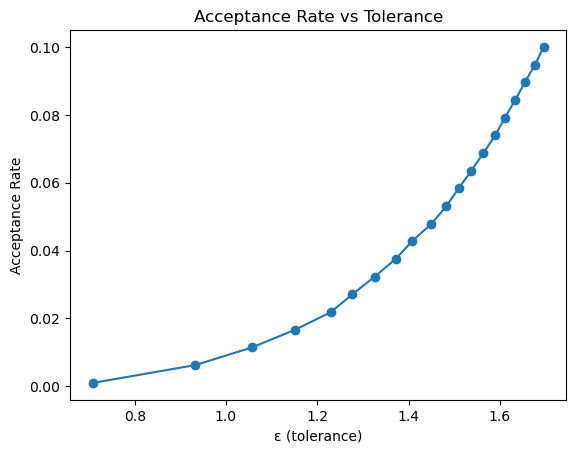

In [72]:
plot_acceptance(epsilons, rates)

In [75]:
# simple linear regression evalutaion
def evaluate_results(thetas, summaries):
    X_train, X_test, y_train, y_test = train_test_split(
        summaries, thetas, test_size=0.2, random_state=42
    )
    # normalize summaries
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

mse_9 = evaluate_results(thetas, summaries)
mse_5 = evaluate_results(thetas5, summaries5)
mse_6 = evaluate_results(thetas6, summaries6)
mse_8 = evaluate_results(thetas8, summaries8)
mse_l = evaluate_results(thetasl, summariesl)

print(f"MSE of summary_stats_9: {mse_9:.5f}")
print(f"MSE of summary_stats_5: {mse_5:.5f}")
print(f"MSE of summary_stats_6: {mse_6:.5f}")
print(f"MSE of summary_stats_8: {mse_8:.5f}")
print(f"MSE of summary_stats_l: {mse_l:.5f}")

MSE of summary_stats_9: 0.00363
MSE of summary_stats_5: 0.00614
MSE of summary_stats_6: 0.00656
MSE of summary_stats_8: 0.00368
MSE of summary_stats_l: 0.00363


In [74]:
# cross-validation evaluation
def evaluate_results(thetas, summaries):
    model = make_pipeline(
        StandardScaler(),
        LinearRegression()
    )

    scores = cross_val_score(
        model,
        summaries,
        thetas,
        scoring='neg_mean_squared_error',
        cv=5
    )

    return -scores.mean(), scores.std()

mse_9,std9 = evaluate_results(thetas, summaries)
mse_5,std5 = evaluate_results(thetas5, summaries5)
mse_6,std6 = evaluate_results(thetas6, summaries6)
mse_8,std8 = evaluate_results(thetas8, summaries8)
mse_l,stdl = evaluate_results(thetasl, summariesl)

print(f"Cross validation evalutaion of summary_stats_9: MSE = {mse_9:.5f}, std = {std9:.5f}")
print(f"Cross validation evalutaion of summary_stats_5: MSE = {mse_5:.5f}, std = {std5:.5f}")
print(f"Cross validation evalutaion of summary_stats_6: MSE = {mse_6:.5f}, std = {std6:.5f}")
print(f"Cross validation evalutaion of summary_stats_8: MSE = {mse_8:.5f}, std = {std8:.5f}")
print(f"Cross validation evalutaion of summary_stats_l: MSE = {mse_l:.5f}, std = {stdl:.5f}")

Cross validation evalutaion of summary_stats_9: MSE = 0.00352, std = 0.00007
Cross validation evalutaion of summary_stats_5: MSE = 0.00638, std = 0.00025
Cross validation evalutaion of summary_stats_6: MSE = 0.00611, std = 0.00017
Cross validation evalutaion of summary_stats_8: MSE = 0.00360, std = 0.00004
Cross validation evalutaion of summary_stats_l: MSE = 0.00362, std = 0.00006


rejection_abc_quantile(n_samples=20000,
    s_obs=s5_obs,
    rng=rng)

In [82]:
def abc_test_with_train_test(thetas, summaries, dist, samples, epsilons, posterior_sample_size, quantile=0.05):

    distances = dist

    accepted_thetas, epsilon = samples, epsilons

    R = 40  # number of replicates
    all_summaries = []

    for _ in range(R):
        infected, rewiring, degree = simulate(*sample_prior(rng), rng=None)
        s = compute_summary(infected, rewiring, degree)
        all_summaries.append(s)

    all_summaries = np.array(all_summaries) 
    summary_train, summary_test = train_test_split(
        all_summaries, test_size=0.2, random_state=42
    )

    posterior_indices = rng.choice(len(accepted_thetas), size=posterior_sample_size, replace=False)
    posterior_thetas = accepted_thetas[posterior_indices]

    posterior_summaries = []
    for theta in posterior_thetas:
        infected, rewiring, degree = simulate(*theta, rng=rng)
        posterior_summaries.append(compute_summary(infected, rewiring, degree))

    posterior_summaries = np.array(posterior_summaries).T
    #error = np.mean(np.linalg.norm(summary_test - posterior_summaries, axis=1)**2)

    errors = np.linalg.norm(posterior_summaries.T[:, None, :] - summary_test[None, :, :], axis=2)**2
    error = np.mean(errors)

    std_params = np.std(posterior_thetas, axis=0)

    return error, std_params, posterior_summaries

In [90]:
error9, std_params9, posterior_summaries9 = abc_test_with_train_test(thetas, summaries, dists, samples, epsilon, posterior_sample_size=50, quantile=0.05)
error8, std_params8, posterior_summaries8 = abc_test_with_train_test(thetas8, summaries8, dists8, samples8, epsilon8, posterior_sample_size=50, quantile=0.05)
error5, std_params5, posterior_summaries5 = abc_test_with_train_test(thetas5, summaries5, dists5, samples5, epsilon5, posterior_sample_size=50, quantile=0.05)
error6, std_params6, posterior_summaries6 = abc_test_with_train_test(thetas6, summaries6, dists6, samples6, epsilon6, posterior_sample_size=50, quantile=0.05)
errorl, std_paramsl, posterior_summariesl = abc_test_with_train_test(thetasl, summariesl, distsl, samplesl, epsilonl, posterior_sample_size=50, quantile=0.05)

print(f"MSE of summary_stats_9: {error9}, std: {std_params9}")
print(f"MSE of summary_stats_5: {error5}, std: {std_params5}")
print(f"MSE of summary_stats_6: {error6}, std: {std_params6}")
print(f"MSE of summary_stats_8: {error8}, std: {std_params8}")
print(f"MSE of summary_stats_l: {errorl}, std: {std_paramsl}")

MSE of summary_stats_9: 125770.11093071509, std: [0.05274708 0.03023177 0.09268148]
MSE of summary_stats_5: 318430.47968642233, std: [0.07914869 0.02368654 0.1359157 ]
MSE of summary_stats_6: 115488.2672404838, std: [0.06021302 0.03291552 0.13176195]
MSE of summary_stats_8: 138282.2046111218, std: [0.07569769 0.03951593 0.10373331]
MSE of summary_stats_l: 130834.40138846498, std: [0.05165328 0.03772286 0.09108587]
